<a href="https://colab.research.google.com/github/bhavinidugar/fstprj/blob/main/option_pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Option Pricing Models
### Black-Scholes | Monte Carlo | Binomial Tree | Greeks | Implied Volatility


In [ ]:
!pip install yfinance scipy numpy matplotlib seaborn scikit-learn xgboost --quiet

## 1. Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
from scipy.optimize import brentq
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

plt.rcParams.update({'font.size': 14, 'lines.linewidth': 2, 'figure.dpi': 100})
print('All imports successful!')

All imports successful!


## 2. User Inputs — Change These

In [ ]:
# ── USER INPUTS ──────────────────────────────────────────
TICKER         = 'AAPL'      # Stock ticker
OPTION_TYPE    = 'call'      # 'call' or 'put'
K              = 285.0       # Strike price
DAYS_TO_EXPIRY = 30          # Days to expiration
RISK_FREE_RATE = 0.043        # Annual risk-free rate (decimal)
MARKET_PRICE   = 10.5       # Market price of the option (for IV)
MC_SIMS        = 10000       # Monte Carlo simulations
BT_STEPS       = 100         # Binomial Tree steps
VOL_START      = '2024-06-01'  # Historical vol start date
VOL_END        = datetime.today().strftime('%Y-%m-%d')  # Historical vol end date
# ─────────────────────────────────────────────────────────

T = DAYS_TO_EXPIRY / 365
print(f'Parameters set: {TICKER} | {OPTION_TYPE.upper()} | K={K} | T={DAYS_TO_EXPIRY}d | r={RISK_FREE_RATE}')

Parameters set: AAPL | CALL | K=285.0 | T=30d | r=0.043


## 3. Data Handler — Fetch Stock Price & Historical Volatility

In [ ]:
def get_stock_price(ticker):
    """Fetch current stock price from Yahoo Finance."""
    try:
        data = yf.download(ticker, period='1d', auto_adjust=True, progress=False)
        if hasattr(data.columns, 'levels'):
            data.columns = data.columns.get_level_values(0)
        if data.empty or 'Close' not in data.columns:
            raise ValueError('No data found.')
        return float(data['Close'].iloc[-1])
    except Exception as e:
        print(f'Error: {e}')
        return None

def calculate_historical_volatility(ticker, start_date, end_date):
    """Calculate annualised historical volatility."""
    try:
        data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
        if hasattr(data.columns, 'levels'):
            data.columns = data.columns.get_level_values(0)
        if data.empty or 'Close' not in data.columns:
            raise ValueError('No data found.')
        returns = data['Close'].pct_change().dropna()
        return float(returns.std() * np.sqrt(252))
    except Exception as e:
        print(f'Error: {e}')
        return None

S = get_stock_price(TICKER)
sigma = calculate_historical_volatility(TICKER, VOL_START, VOL_END)

print(f'Current Stock Price (S): ${S:.2f}')
print(f'Historical Volatility:   {sigma*100:.2f}%')

Current Stock Price (S): $283.78
Historical Volatility:   28.51%


## 4. Option Pricing Models

In [ ]:
# ── BLACK-SCHOLES ────────────────────────────────────────
def black_scholes(S, K, T, r, sigma, option_type='call', q=0):
    """Black-Scholes closed-form option price."""
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

# ── BINOMIAL TREE ────────────────────────────────────────
def binomial_tree(S, K, T, r, sigma, option_type='call', N=100):
    """Binomial Tree option price via backward induction."""
    dt = T / N
    u  = np.exp(sigma * np.sqrt(dt))
    d  = 1 / u
    p  = (np.exp(r * dt) - d) / (u - d)
    ST = np.array([S * (u**(N-i)) * (d**i) for i in range(N+1)])
    vals = np.maximum(0, ST - K) if option_type == 'call' else np.maximum(0, K - ST)
    for _ in range(N):
        vals = np.exp(-r * dt) * (p * vals[:-1] + (1-p) * vals[1:])
    return vals[0]

# ── MONTE CARLO ──────────────────────────────────────────
def monte_carlo(S, K, T, r, sigma, option_type='call', num_simulations=10000):
    """Monte Carlo simulation via Geometric Brownian Motion."""
    dt = 1/365
    num_steps = int(T * 365)
    payoffs = []
    paths = []
    estimated_prices = []

    for _ in range(num_simulations):
        ST   = S
        path = [S]
        for _ in range(num_steps):
            Z  = np.random.normal()
            ST *= np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
            path.append(ST)
        paths.append(path)
        payoff = max(0, ST - K) if option_type == 'call' else max(0, K - ST)
        payoffs.append(payoff)
        estimated_prices.append(np.exp(-r*T) * np.mean(payoffs))

    return np.exp(-r*T) * np.mean(payoffs), paths, payoffs, estimated_prices

# ── RUN ALL MODELS ───────────────────────────────────────
bs_price                              = black_scholes(S, K, T, RISK_FREE_RATE, sigma, OPTION_TYPE)
bt_price                              = binomial_tree(S, K, T, RISK_FREE_RATE, sigma, OPTION_TYPE, BT_STEPS)
mc_price, mc_paths, mc_payoffs, mc_conv = monte_carlo(S, K, T, RISK_FREE_RATE, sigma, OPTION_TYPE, MC_SIMS)

print(f'\n── Option Prices ({OPTION_TYPE.upper()}) ──────────────────')
print(f'Black-Scholes : ${bs_price:.4f}')
print(f'Binomial Tree : ${bt_price:.4f}')
print(f'Monte Carlo   : ${mc_price:.4f}')
print(f'Max deviation : ${max(abs(bs_price-bt_price), abs(bs_price-mc_price)):.4f}')


── Option Prices (CALL) ──────────────────
Black-Scholes : $9.1467
Binomial Tree : $9.1593
Monte Carlo   : $9.2246
Max deviation : $0.0779


## 5. Greeks

In [ ]:
def calculate_greeks(S, K, T, r, sigma, option_type='call', q=0):
    """Compute all 5 Greeks via closed-form Black-Scholes derivations."""
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * np.exp(-q*T) * norm.pdf(d1) * np.sqrt(T)

    if option_type == 'call':
        delta = norm.cdf(d1)
        theta = (-(S * np.exp(-q*T) * norm.pdf(d1) * sigma) / (2*np.sqrt(T))
                 - r * K * np.exp(-r*T) * norm.cdf(d2))
        rho   = K * T * np.exp(-r*T) * norm.cdf(d2)
    else:
        delta = norm.cdf(d1) - 1
        theta = (-(S * np.exp(-q*T) * norm.pdf(d1) * sigma) / (2*np.sqrt(T))
                 + r * K * np.exp(-r*T) * norm.cdf(-d2))
        rho   = -K * T * np.exp(-r*T) * norm.cdf(-d2)

    return delta, gamma, vega, theta/365, rho

delta, gamma, vega, theta, rho = calculate_greeks(S, K, T, RISK_FREE_RATE, sigma, OPTION_TYPE)

print(f'\n── Greeks ────────────────────────────────────────')
print(f'Delta : {delta:.4f}  (price sensitivity to S)')
print(f'Gamma : {gamma:.4f}  (rate of change of Delta)')
print(f'Vega  : {vega:.4f}  (sensitivity to volatility)')
print(f'Theta : {theta:.4f}  (daily time decay)')
print(f'Rho   : {rho:.4f}  (sensitivity to interest rate)')


── Greeks ────────────────────────────────────────
Delta : 0.5126  (price sensitivity to S)
Gamma : 0.0172  (rate of change of Delta)
Vega  : 32.4406  (sensitivity to volatility)
Theta : -0.1702  (daily time decay)
Rho   : 11.2046  (sensitivity to interest rate)


## 6. Implied Volatility

In [ ]:
def implied_vol_newton(S, K, T, r, market_price, option_type='call',
                       max_iter=10000, tol=1e-6, relax=0.15):
    """Implied volatility via Newton-Raphson."""
    sig = 0.2
    for _ in range(max_iter):
        price = black_scholes(S, K, T, r, sig, option_type)
        _, _, vega_val, _, _ = calculate_greeks(S, K, T, r, sig, option_type)
        diff  = price - market_price
        if abs(diff) < tol:
            return sig
        if vega_val == 0:
            raise ValueError('Vega is zero.')
        sig -= relax * (diff / vega_val)
        sig  = max(0.01, min(5.0, sig))
    raise ValueError('Newton-Raphson did not converge.')

def implied_vol_bisection(S, K, T, r, market_price, option_type='call',
                          lo=0.01, hi=5.0, max_iter=100, tol=1e-6):
    """Implied volatility via Bisection."""
    def diff(s): return black_scholes(S, K, T, r, s, option_type) - market_price
    if diff(lo) * diff(hi) > 0:
        raise ValueError('Bisection brackets invalid.')
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        if abs(diff(mid)) < tol: return mid
        if diff(lo) * diff(mid) < 0: hi = mid
        else: lo = mid
    raise ValueError('Bisection did not converge.')

def implied_vol_brent(S, K, T, r, market_price, option_type='call'):
    """Implied volatility via Brent's method."""
    def diff(s): return black_scholes(S, K, T, r, s, option_type) - market_price
    if diff(1e-6) * diff(10) > 0:
        return None
    return brentq(diff, 1e-6, 10)

def implied_volatility(S, K, T, r, market_price, option_type='call'):
    """Cascade: Newton-Raphson → Bisection → Brent."""
    try:
        iv = implied_vol_newton(S, K, T, r, market_price, option_type)
        print('Converged via Newton-Raphson.')
        return iv
    except Exception as e:
        print(f'Newton-Raphson failed: {e} — trying Bisection.')
    try:
        iv = implied_vol_bisection(S, K, T, r, market_price, option_type)
        print('Converged via Bisection.')
        return iv
    except Exception as e:
        print(f'Bisection failed: {e} — trying Brent.')
    return implied_vol_brent(S, K, T, r, market_price, option_type)

iv = implied_volatility(S, K, T, RISK_FREE_RATE, MARKET_PRICE, OPTION_TYPE)
print(f'\n── Implied Volatility ──────────────────────────────')
print(f'Market Price    : ${MARKET_PRICE}')
print(f'Implied Vol     : {iv*100:.2f}%')
print(f'Historical Vol  : {sigma*100:.2f}%')
print(f'IV / HV Premium : {iv/sigma:.2f}x')

Converged via Newton-Raphson.

── Implied Volatility ──────────────────────────────
Market Price    : $10.5
Implied Vol     : 32.68%
Historical Vol  : 28.51%
IV / HV Premium : 1.15x


## 7. Plots

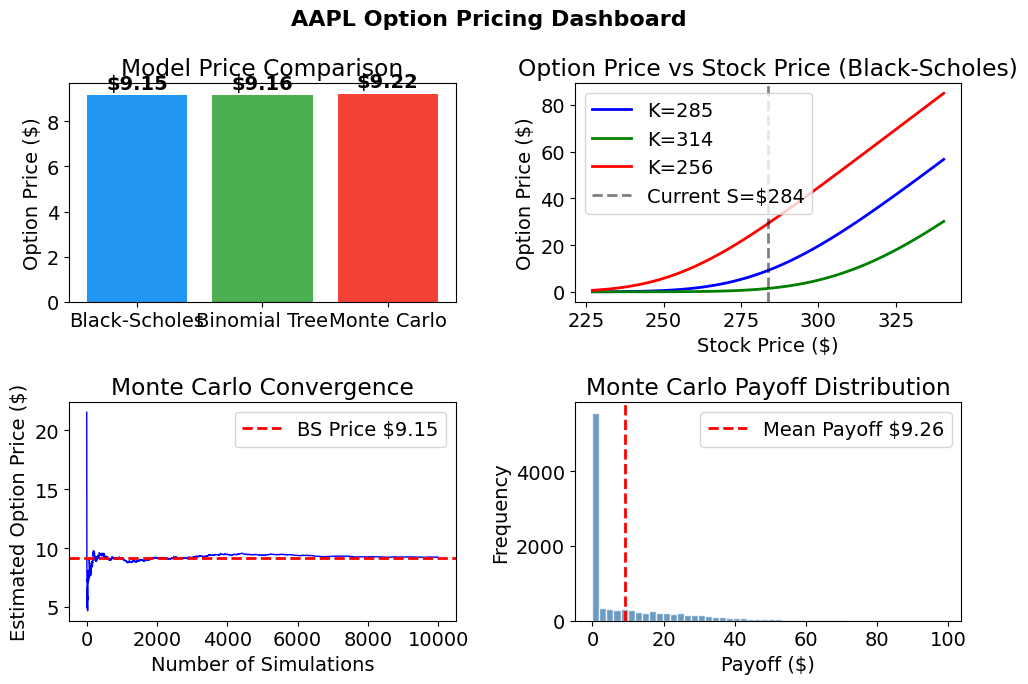

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle(f'{TICKER} Option Pricing Dashboard', fontsize=16, fontweight='bold')

# ── Plot 1: Comparative Pricing ───────────────────────────
ax1 = axes[0, 0]
methods = ['Black-Scholes', 'Binomial Tree', 'Monte Carlo']
prices  = [bs_price, bt_price, mc_price]
bars    = ax1.bar(methods, prices, color=['#2196F3', '#4CAF50', '#F44336'])
for bar, price in zip(bars, prices):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'${price:.2f}', ha='center', va='bottom', fontweight='bold')
ax1.set_title('Model Price Comparison')
ax1.set_ylabel('Option Price ($)')

# ── Plot 2: Option Price vs Stock Price ───────────────────
ax2 = axes[0, 1]
S_range = np.linspace(S * 0.8, S * 1.2, 100)
for K_plot, col in zip([K, K*1.1, K*0.9], ['blue','green','red']):
    prices_plot = [black_scholes(s, K_plot, T, RISK_FREE_RATE, sigma, OPTION_TYPE) for s in S_range]
    ax2.plot(S_range, prices_plot, color=col, label=f'K={K_plot:.0f}')
ax2.axvline(S, color='black', linestyle='--', alpha=0.5, label=f'Current S=${S:.0f}')
ax2.set_title('Option Price vs Stock Price (Black-Scholes)')
ax2.set_xlabel('Stock Price ($)')
ax2.set_ylabel('Option Price ($)')
ax2.legend()

# ── Plot 3: Monte Carlo Convergence ──────────────────────
ax3 = axes[1, 0]
ax3.plot(mc_conv, color='blue', linewidth=1)
ax3.axhline(bs_price, color='red', linestyle='--', label=f'BS Price ${bs_price:.2f}')
ax3.set_title('Monte Carlo Convergence')
ax3.set_xlabel('Number of Simulations')
ax3.set_ylabel('Estimated Option Price ($)')
ax3.legend()

# ── Plot 4: Monte Carlo Payoff Histogram ─────────────────
ax4 = axes[1, 1]
ax4.hist(mc_payoffs, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax4.axvline(np.mean(mc_payoffs), color='red', linestyle='--',
            label=f'Mean Payoff ${np.mean(mc_payoffs):.2f}')
ax4.set_title('Monte Carlo Payoff Distribution')
ax4.set_xlabel('Payoff ($)')
ax4.set_ylabel('Frequency')
ax4.legend()

plt.tight_layout()
plt.show()

## 8. Monte Carlo Stock Price Paths

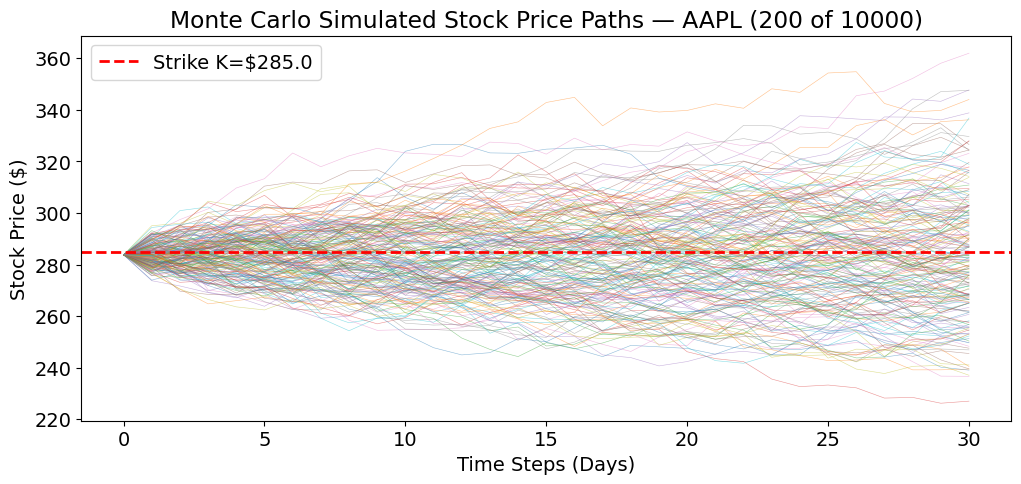

In [ ]:
plt.figure(figsize=(12, 5))
for path in mc_paths[:200]:
    plt.plot(path, linewidth=0.4, alpha=0.5)
plt.axhline(K, color='red', linestyle='--', linewidth=2, label=f'Strike K=${K}')
plt.title(f'Monte Carlo Simulated Stock Price Paths — {TICKER} (200 of {MC_SIMS})')
plt.xlabel('Time Steps (Days)')
plt.ylabel('Stock Price ($)')
plt.legend()
plt.show()

## 9. Summary Report

In [ ]:
print('=' * 55)
print('       OPTION PRICING REPORT')
print('=' * 55)
print(f'Ticker          : {TICKER}')
print(f'Option Type     : {OPTION_TYPE.upper()}')
print(f'Stock Price (S) : ${S:.2f}')
print(f'Strike Price (K): ${K}')
print(f'Days to Expiry  : {DAYS_TO_EXPIRY}')
print(f'Risk-Free Rate  : {RISK_FREE_RATE*100:.1f}%')
print(f'Hist. Volatility: {sigma*100:.2f}%')
print('-' * 55)
print('OPTION PRICES')
print(f'  Black-Scholes : ${bs_price:.4f}')
print(f'  Binomial Tree : ${bt_price:.4f}')
print(f'  Monte Carlo   : ${mc_price:.4f}')
print(f'  Max Deviation : ${max(abs(bs_price-bt_price), abs(bs_price-mc_price)):.4f}')
print('-' * 55)
print('GREEKS')
print(f'  Delta : {delta:.4f}')
print(f'  Gamma : {gamma:.4f}')
print(f'  Vega  : {vega:.4f}')
print(f'  Theta : {theta:.4f}')
print(f'  Rho   : {rho:.4f}')
print('-' * 55)
print('IMPLIED VOLATILITY')
print(f'  Market Price  : ${MARKET_PRICE}')
print(f'  Implied Vol   : {iv*100:.2f}%')
print(f'  IV/HV Premium : {iv/sigma:.2f}x')
print('=' * 55)

       OPTION PRICING REPORT
Ticker          : AAPL
Option Type     : CALL
Stock Price (S) : $283.78
Strike Price (K): $285.0
Days to Expiry  : 30
Risk-Free Rate  : 4.3%
Hist. Volatility: 28.51%
-------------------------------------------------------
OPTION PRICES
  Black-Scholes : $9.1467
  Binomial Tree : $9.1593
  Monte Carlo   : $9.2246
  Max Deviation : $0.0779
-------------------------------------------------------
GREEKS
  Delta : 0.5126
  Gamma : 0.0172
  Vega  : 32.4406
  Theta : -62.1206
  Rho   : 11.2046
-------------------------------------------------------
IMPLIED VOLATILITY
  Market Price  : $10.5
  Implied Vol   : 32.68%
  IV/HV Premium : 1.15x
